# Hazard forecasts and impacts forecasts

In this tutorial, we showcase CLIMADA functionality to handle forecast data using the classes {py:class}`~climada.hazard.forecast.HazardForecast` and {py:class}`~climada.engine.impact_forecast.ImpactForecast`.
Exemplary forecast data will be downloaded from the Open Government Data (OGD) portal of MeteoSwiss.

## Table of Contents

0. [Quickstart](#0-quickstart)
1. [Reading & processing forecast data](#1-reading--processing-forecast-data)
   - 1.1 [Using MeteoSwiss Open Government Data weather forecasts](#11-using-meteoswiss-open-government-data-weather-forecasts)
   - 1.2 [Using CLIMADA API demo data](#12-using-climada-api-demo-data)
2. [Impact Forecast calculation](#2-impact-forecast-calculation)
3. [Products based on ImpactForecast](#3-products-based-on-impactforecast)
   - 3.1 [Per ensemble member, per lead time](#31-per-ensemble-member-per-lead-time)
   - 3.2 [All ensemble members, per lead time](#32-all-ensemble-members-per-lead-time)
   - 3.3 [All ensemble members and lead times](#33-all-ensemble-members-and-lead-times)

In [1]:
# import necessary packages
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

# import numbers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# Import CLIMADA
from climada.engine import ImpactCalc, ImpactForecast
from climada.entity import ImpactFunc, ImpactFuncSet
from climada.entity.exposures.litpop import LitPop
from climada.hazard.forecast import HazardForecast
from climada.util.api_client import Client

# Features for maps
admin1 = cfeature.NaturalEarthFeature(
    category="cultural", name="admin_1_states_provinces_lines", scale="10m"
)
lakes = cfeature.LAKES.with_scale("10m")
borders = cfeature.BORDERS.with_scale("10m")

## 0. Quickstart

The next cell downloads some exemplary forecast data and loads it as a `HazardForecast` object.
It then demonstrates the capabilities of this class:

* Computing reductions (in this case maximum) over the lead time or member dimensions.
* Regular impact calculation with `ImpactCalc` yielding an `ImpactForecast` object.
* More reductions and the use of other methods from `Impact`.

/Users/ldr.riedel/coding/climada_python/climada/hazard/forecast.py:479: FutureWarning: In a future version, xarray will not decode the variable 'lead_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dset = xr.open_dataset(data, **open_dataset_kws)


2026-04-10 14:02:32,546 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates. Hazard.event_name will be empty strings
2026-04-10 14:02:32,547 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates or ordinals. Hazard.date will be ones only
2026-04-10 14:02:33,193 - climada.entity.exposures.litpop.litpop - INFO - 
 LitPop: Init Exposure for country: CHE (756)...

2026-04-10 14:02:33,320 - climada.entity.exposures.litpop.litpop - INFO - 
 LitPop: Init Exposure for country: LIE (438)...

2026-04-10 14:02:33,354 - climada.entity.exposures.base - INFO - Hazard type not set in impf_
2026-04-10 14:02:33,354 - climada.entity.exposures.base - INFO - category_id not set.
2026-04-10 14:02:33,355 - climada.entity.exposures.base - INFO - cover not set.
2026-04-10 14:02:33,355 - climada.entity.exposures.base - INFO - deductible not set.
2026-04-10 14:02:33,355 - climada.entity.exposures.base - INFO - centr_ not set.
2026-04-10 14:02:33,355 - climada.en

<GeoAxes: >

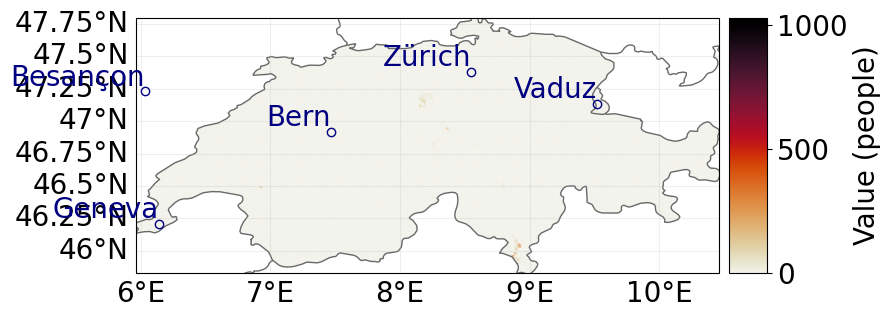

In [2]:
# Load example hazard data
client = Client()
ds_info_icon_fcst = client.get_dataset_info_by_uuid(
    "60229fa0-4d5d-4f39-876c-b4344579d6eb"
)
_, path_to_forecast_nc = client.download_dataset(ds_info_icon_fcst)

# Read data as HazardForecast object
hazard_forecast = HazardForecast.from_xarray_raster(
    path_to_forecast_nc[0],
    hazard_type="PR",
    intensity_unit="mm/h",
    coordinate_vars={
        "longitude": "x",
        "latitude": "y",
        "lead_time": "lead_time",
        "member": "realization",
    },
    intensity="precipitation_amount_1hsum",
    crs="EPSG:2056",
)
# transform to EPSG:4326
hazard_forecast.centroids.gdf = hazard_forecast.centroids.gdf.to_crs(epsg=4326)

# For each member, use the maximum intensity over the lead time
hazard_forecast = hazard_forecast.max(dim="lead_time")

# Read exposure for population
exp_che = LitPop.from_population(countries=["CHE", "LIE"], res_arcsec=30)
# Assign centroids because hazard not on regular grid
exp_che.assign_centroids(hazard_forecast, threshold=100)

# Define impact functions
threshold_for_affected = 50
imp_fun_precip = ImpactFunc.from_step_impf(
    (0, threshold_for_affected, 200),
    haz_type="PR",
    impf_id=1,
    intensity_unit="mm/h",
    name="Severe Precipitation Step Function",
)
impf_set = ImpactFuncSet([imp_fun_precip])

# Compute impact (forecast)
impact_forecast = ImpactCalc(exp_che, impf_set, hazard_forecast).impact(
    assign_centroids=False, save_mat=True
)

# Compute quantile over remaining ensemble members and plot
impact_forecast_q075 = impact_forecast.quantile(0.92)
impact_forecast_q075.plot_hexbin_impact_exposure()


## 1. Reading & processing forecast data


### 1.1 Using MeteoSwiss Open Government Data weather forecasts

This example retrieves the latest OGD forecast data from MeteoSwiss.
You can also skip this step and go to section 1.2 for using stored demo data from the CLIMADA API.

Requires the package `meteodata-lab`, available via `pip`.

You can find out all about data openly published here (info and notebooks on how to retrieve):

Check out:
* https://github.com/MeteoSwiss/meteodata-lab and
* https://github.com/MeteoSwiss/opendata-nwp-demos/blob/main/01_retrieve_process_precip.ipynb
* https://www.meteoschweiz.admin.ch/service-und-publikationen/service/open-data.html



In [3]:
!pip install meteodata-lab

In [4]:
# optional packages for this section only
from earthkit.data import config
from meteodatalab import ogd_api
from meteodatalab.operators import time_operators as time_ops

config.set("cache-policy", "temporary")

In [5]:
# Define target lead times for ICON-CH2-EPS: up 5d, here +0h, to +12h
lead_times = [f"P0DT{i}H" for i in np.arange(0, 13)]
model = "ogd-forecasting-icon-ch2"
nwp_vars = ["TOT_PREC", "VMAX_10M"]  # precip. and wind; temperature: "T_2M"
reftime = "latest"  # also try: 'latest'

In [ ]:
dict_ens_data = {}
for var in nwp_vars:
    req = ogd_api.Request(
        collection=model,
        variable=var,
        ref_time=reftime,
        perturbed=True,  # ensembles
        lead_time=lead_times,
    )
    dict_ens_data[var] = ogd_api.get_from_ogd(req)

# We extract the hourly delta in total precipitation to receive the hourly precipitation
dict_ens_data["TOT_PREC"] = time_ops.delta(
    dict_ens_data["TOT_PREC"], np.timedelta64(1, "h")
)

<multiple>: 0.00B [00:00, ?B/s]

horizontal_constants_icon-ch2-eps.grib2?AWSAccessKeyId=13GC1T4NT2CY1N0L92YC&Signature=mo0z8gI5lpIvRiUr5P9fpVoa…

<multiple>: 0.00B [00:00, ?B/s]

In [7]:
ds_icon_latest = xr.Dataset(dict_ens_data)
init_time_str = np.datetime_as_string(ds_icon_latest.ref_time.values[0], unit="h")

After loading the data as a netcdf file, we read it into a `HazardForecast` object (see next subsection for more details on the structuer of this class).

In [8]:
haz_fc_icon_latest = HazardForecast.from_xarray_raster(
    ds_icon_latest,
    hazard_type="PR",
    intensity_unit="mm/h",
    coordinate_vars={
        "longitude": "lon",
        "latitude": "lat",
        "lead_time": "lead_time",
        "member": "eps",
    },
    intensity="TOT_PREC",
)

2026-04-10 14:03:02,854 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates. Hazard.event_name will be empty strings
2026-04-10 14:03:02,855 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates or ordinals. Hazard.date will be ones only


Text(0.5, 1.0, 'Forecasted hourly precipication (model: ogd-forecasting-icon-ch2) for init time 2026-04-10T06 (UTC),\nmaximized over 20 ensemble members and 13 lead times (0 hours - 12 hours)')

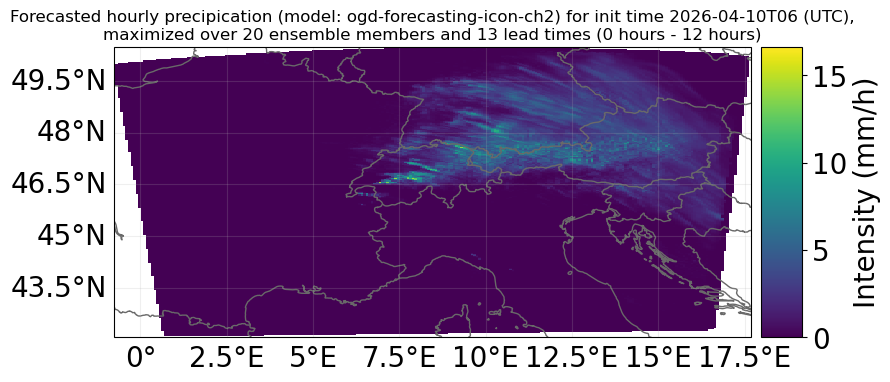

In [9]:
# Plot the maximum precipitation intensity for each pixel in the entire dataset
ax = haz_fc_icon_latest.plot_intensity(event=0)
lead_times = np.unique(haz_fc_icon_latest.lead_time).astype("timedelta64[h]")
ax.set_title(
    f"Forecasted hourly precipication (model: {model}) for init time {init_time_str} "
    f"(UTC),\nmaximized over {len(np.unique(haz_fc_icon_latest.member))} ensemble "
    f"members and {len(lead_times)} lead times ({lead_times[0]} - {lead_times[-1]})"
)

### 1.2 Using CLIMADA API demo data

As an example, we load existing forecast data for an event including heavy precipitation and flooding on June 21, 2024 in in Misox, Switzerland.

After loading the data as a netcdf file, we read it into a `HazardForecast` object.

In [10]:
# get the demo forecast netCDF file fcst_icon_seamless_2024-06-18_12_00.nc via CLIMADA API
client = Client()
ds_info_icon_fcst = client.get_dataset_info_by_uuid(
    "60229fa0-4d5d-4f39-876c-b4344579d6eb"
)
_, path_to_forecast_nc = client.download_dataset(ds_info_icon_fcst)

Load into `HazardForecast` file from NetCDF on disk.

In [11]:
hazard_forecast = HazardForecast.from_xarray_raster(
    path_to_forecast_nc[0],
    hazard_type="PR",
    intensity_unit="mm/h",
    coordinate_vars={
        "longitude": "x",
        "latitude": "y",
        "lead_time": "lead_time",
        "member": "realization",
    },
    intensity="precipitation_amount_1hsum",
    crs="EPSG:2056",
)
# transform to EPSG:4326
hazard_forecast.centroids.gdf = hazard_forecast.centroids.gdf.to_crs(epsg=4326)

/Users/ldr.riedel/coding/climada_python/climada/hazard/forecast.py:479: FutureWarning: In a future version, xarray will not decode the variable 'lead_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dset = xr.open_dataset(data, **open_dataset_kws)


2026-04-10 14:03:20,825 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates. Hazard.event_name will be empty strings
2026-04-10 14:03:20,825 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates or ordinals. Hazard.date will be ones only


`HazardForecast` objects include forecasts produced at a specific initializatio (or reference) time, but for several several lead times and several forecast ensemble members. For this, it includes the two array-like attributes:
- `member` to indicate the forecast ensemble member, and
- `lead_time` to indicate the lead time of the data,

both of which can be used to select specific forecasts.

In [12]:
pd.DataFrame.from_records(
    {
        "member": hazard_forecast.member,
        "lead_time": hazard_forecast.lead_time,
        "event_name": hazard_forecast.event_name,
        "event_id": hazard_forecast.event_id,
    }
).head(25)

,event_id,event_name,lead_time,member
0,1,lt_0h_m_0,0 days 00:00:00,0
1,2,lt_0h_m_1,0 days 00:00:00,1
2,3,lt_0h_m_2,0 days 00:00:00,2
3,4,lt_0h_m_3,0 days 00:00:00,3
4,5,lt_0h_m_4,0 days 00:00:00,4
5,6,lt_0h_m_5,0 days 00:00:00,5
6,7,lt_0h_m_6,0 days 00:00:00,6
7,8,lt_0h_m_7,0 days 00:00:00,7
8,9,lt_0h_m_8,0 days 00:00:00,8
9,10,lt_0h_m_9,0 days 00:00:00,9


Text(0.5, 1.0, 'Precipation Forecast for member 10 and lead time 78 hours')

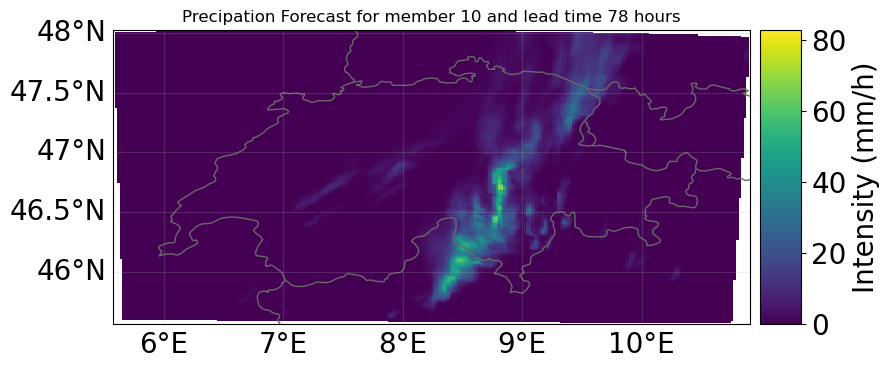

In [13]:
# select hazard forecast for a specific member and a specific lead time
test_member = 10
test_lead_time = np.timedelta64(78, "h")

# plot
ax = hazard_forecast.select(
    member=test_member,
    lead_time=test_lead_time,
).plot_intensity(0)
ax.set_title(
    f"Precipation Forecast for member {test_member} and lead time "
    f"{test_lead_time.astype('timedelta64[h]')}"
)

The two forecast attributes `member` and `lead_time` can be used to generate (centroid-wise) statistics by means of methods like, e.g.,
- `.max()` for the centroid-wise maximum of all lead times and ensemble members
- `.quantile(q=0.3, dim="member")` for the 0.3-quantile of the hazard intensity over all ensemble members, for each lead time and centroid

In [14]:
# Reduce over dimension 'lead_time'
haz_max = hazard_forecast.max(dim="lead_time")
haz_max.member

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20])

This operation reduces over the dimension 'lead_time'.
The associated values are therefore set to placeholders; in this case, Not-a-Time (NaT).

In [15]:
haz_max.lead_time

array(['NaT', 'NaT', 'NaT', 'NaT', 'NaT', 'NaT', 'NaT', 'NaT', 'NaT',
       'NaT', 'NaT', 'NaT', 'NaT', 'NaT', 'NaT', 'NaT', 'NaT', 'NaT',
       'NaT', 'NaT', 'NaT'], dtype=timedelta64)

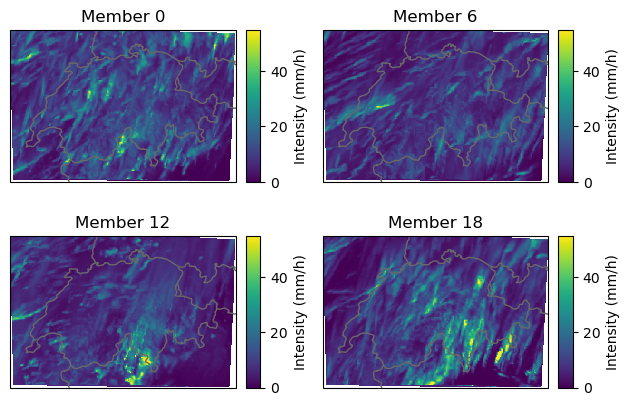

In [16]:
# Plot the centroid-wise maximum over all lead times for 4 select members
fig, axes = plt.subplots(2, 2, subplot_kw={"projection": ccrs.Mercator()})
norm = mcolors.Normalize(vmin=0)
for idx, member in enumerate((0, 6, 12, 18)):
    ax = axes.flat[idx]
    haz_max.select(member=member).plot_intensity(0, axis=ax, norm=norm)
    ax.set_title(f"Member {member}")

We can also reduce over the 'member', leaving us with the ensemble median for each lead time.

In [17]:
haz_med = hazard_forecast.median(dim="member")
haz_med.member, haz_med.lead_time

(array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]),
 array([              0,   3600000000000,   7200000000000,  10800000000000,
         14400000000000,  18000000000000,  21600000000000,  25200000000000,
         28800000000000,  32400000000000,  36000000000000,  39600000000000,
         43200000000000,  46800000000000,  50400000000000,  54000000000000,
         57600000000000,  61200000000000,  64800000000000,  68400000000000,
         72000000000000,  75600000000000,  79200000000000,  82800000000000,
         86400000000000,  

Text(0.5, 1.0, 'Median of members for Precipitation Forecast at lead time 78 hours')

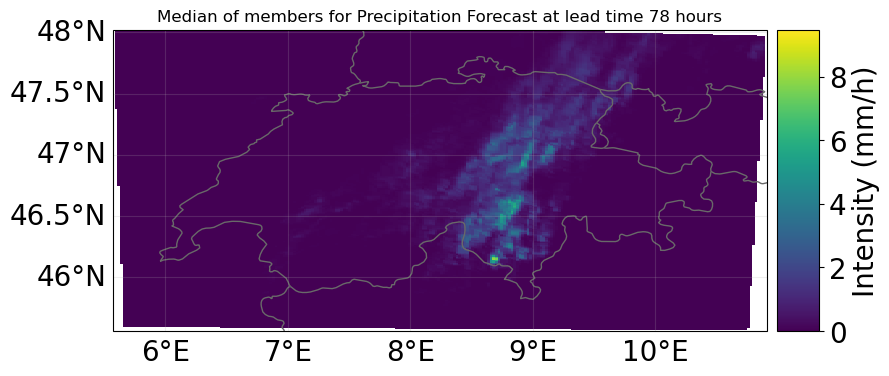

In [18]:
# plot median over member dimension for given a lead time
ax = haz_med.select(lead_time=test_lead_time).plot_intensity(0)
ax.set_title(
    f"Median of members for Precipitation Forecast at lead time {test_lead_time}"
)

While most meteorological data come as `netCDF (.nc)`, `HazardForecast` objects can be 
written to and read from `HDF5 (.h5)` files using the methods:
* `write_hdf5()`
* `from_hdf5()`

In [19]:
from tempfile import TemporaryDirectory

# write hazard forecast object to HDF5 file
with TemporaryDirectory() as tmpdir:
    hazard_forecast.write_hdf5(Path(tmpdir) / "demo_hazard_forecast.h5")

    # read hazard forecast from HDF5 file
    hazard_forecast_read = HazardForecast.from_hdf5(
        Path(tmpdir) / "demo_hazard_forecast.h5"
    )

np.array_equal(
    hazard_forecast_read.intensity.toarray(), hazard_forecast.intensity.toarray()
)

2026-04-10 14:03:34,693 - climada.hazard.io - INFO - Writing /var/folders/9m/w030_m9j2j5gyjdjczm2tf680000gq/T/tmp3rzxqaa5/demo_hazard_forecast.h5
2026-04-10 14:03:34,828 - climada.hazard.centroids.centr - INFO - Writing /var/folders/9m/w030_m9j2j5gyjdjczm2tf680000gq/T/tmp3rzxqaa5/demo_hazard_forecast.h5
2026-04-10 14:03:34,951 - climada.hazard.io - INFO - Reading /var/folders/9m/w030_m9j2j5gyjdjczm2tf680000gq/T/tmp3rzxqaa5/demo_hazard_forecast.h5


True

## 2. Impact Forecast calculation

`HazardForecast` objects can be handed in to the standard `CLIMADA ImpactCalc` engine to produce `ImpactForecast` objects, consisting of one impact forecast per hazard forecast.


We exemplify this below by loading a population exposure layer for Switzerland and Liechtenstein, and by defining a step impact function. This impact function results in impacts describing how much population (how many people) are exposed to a precipitation of more than 50mm/h for the severe precipitation event in Misox loaded above.

2026-04-10 14:03:35,120 - climada.entity.exposures.litpop.litpop - INFO - 
 LitPop: Init Exposure for country: CHE (756)...

2026-04-10 14:03:35,266 - climada.entity.exposures.litpop.litpop - INFO - 
 LitPop: Init Exposure for country: LIE (438)...

2026-04-10 14:03:35,305 - climada.entity.exposures.base - INFO - Hazard type not set in impf_
2026-04-10 14:03:35,306 - climada.entity.exposures.base - INFO - category_id not set.
2026-04-10 14:03:35,306 - climada.entity.exposures.base - INFO - cover not set.
2026-04-10 14:03:35,306 - climada.entity.exposures.base - INFO - deductible not set.
2026-04-10 14:03:35,306 - climada.entity.exposures.base - INFO - centr_ not set.
2026-04-10 14:03:35,314 - climada.entity.exposures.base - INFO - Matching 70525 exposures with 27000 centroids.
2026-04-10 14:03:35,358 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 100 degree


<Axes: title={'center': 'PR 1: Severe Precipitation Step Function'}, xlabel='Intensity (mm/h)', ylabel='Impact (%)'>

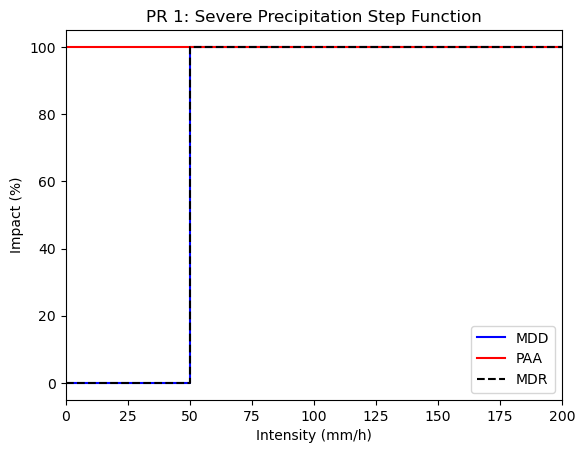

In [20]:
# Read exposure for population
exp_che = LitPop.from_population(countries=["CHE", "LIE"], res_arcsec=30)
# Assign centroids because hazard not on regular grid
exp_che.assign_centroids(hazard_forecast, threshold=100)

# define impact functions
threshold_for_affected = 50
imp_fun_precip = ImpactFunc.from_step_impf(
    (0, threshold_for_affected, 200),
    haz_type="PR",
    impf_id=1,
    intensity_unit="mm/h",
    name="Severe Precipitation Step Function",
)
impf_set = ImpactFuncSet([imp_fun_precip])
impf_set.plot()

In [21]:
# calculate impact
impact_forecast = ImpactCalc(exp_che, impf_set, hazard_forecast).impact(
    assign_centroids=False,  # assign_centroid=False because we do not want to reassign centroids
)  # impact matrix is saved by default

2026-04-10 14:03:35,458 - climada.entity.exposures.base - INFO - No specific impact function column found for hazard PR. Using the anonymous 'impf_' column.
2026-04-10 14:03:35,461 - climada.engine.impact_calc - INFO - Calculating impact for 69394 assets (>0) and 2415 events.
2026-04-10 14:03:35,624 - climada.engine.impact_calc - WARNING - eai_exp and aai_agg are undefined with forecasts. Setting them to NaN arrays.
2026-04-10 14:03:35,630 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


In [22]:
pd.DataFrame.from_records(
    {
        "member": impact_forecast.member,
        "lead_time": impact_forecast.lead_time,
        "event_name": impact_forecast.event_name,
        "event_id": impact_forecast.event_id,
    }
).head(25)

,event_id,event_name,lead_time,member
0,1,lt_0h_m_0,0 days 00:00:00,0
1,2,lt_0h_m_1,0 days 00:00:00,1
2,3,lt_0h_m_2,0 days 00:00:00,2
3,4,lt_0h_m_3,0 days 00:00:00,3
4,5,lt_0h_m_4,0 days 00:00:00,4
5,6,lt_0h_m_5,0 days 00:00:00,5
6,7,lt_0h_m_6,0 days 00:00:00,6
7,8,lt_0h_m_7,0 days 00:00:00,7
8,9,lt_0h_m_8,0 days 00:00:00,8
9,10,lt_0h_m_9,0 days 00:00:00,9


## 3. Products based on ImpactForecast

We can now analyse the impact forecasts by selecting specific ensemble member or lead times (or other impact attributes), or by computing statistics (min, max, quantile, mean) over the forecast dimensions `member` and `lead_time`.

For the specific case of Misox, we will zoom in to the canton of Ticino which was most heavily affected.

### 3.1 Per ensemble member, per lead time

2026-04-10 14:03:35,674 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.


Text(0.5, 1.0, 'Affected people from precip>50mm/h\nfor member 10 and lead time 78 hours')

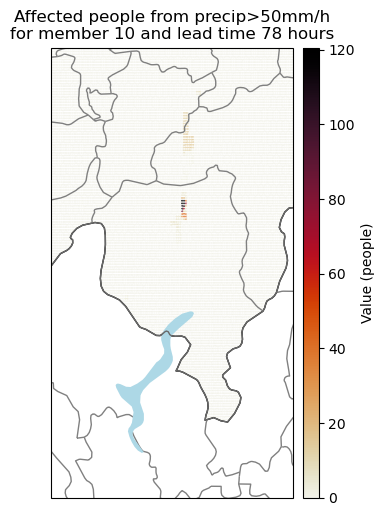

In [23]:
# select for a specific member and a specific lead time and plot Ticino extent

impact_forecast_1m_1lt = impact_forecast.select(
    member=test_member,
    lead_time=test_lead_time,
)
extent_ticino = [8.2, 9.3, 45.58, 47]

fig = plt.figure()
ax = plt.axes(projection=ccrs.Mercator())
ax.add_feature(borders, linewidth=1)
ax.add_feature(admin1, edgecolor="gray", linewidth=1.0, facecolor="none")
ax.add_feature(lakes, facecolor="lightblue")

# plot impact forecast
impact_forecast_1m_1lt.plot_hexbin_impact_exposure(
    event_id=impact_forecast_1m_1lt.event_id, pop_name=False, axis=ax
)
ax.set_extent(extent_ticino)
ax.set_title(
    f"Affected people from precip>{threshold_for_affected}mm/h\nfor member "
    f"{test_member} and lead time {test_lead_time.astype('timedelta64[h]')}"
)

### 3.2 All ensemble members, per lead time

We can now easily compute the centroid-wise maximum impact over all lead times for each ensemble member.

In [24]:
imp_fct_all_mem_1lt = impact_forecast.max(dim="lead_time")

2026-04-10 14:03:38,318 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold
2026-04-10 14:03:38,319 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold
2026-04-10 14:03:38,321 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold
2026-04-10 14:03:38,322 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold
2026-04-10 14:03:38,324 - climada.engine.impact - WARNING - The 

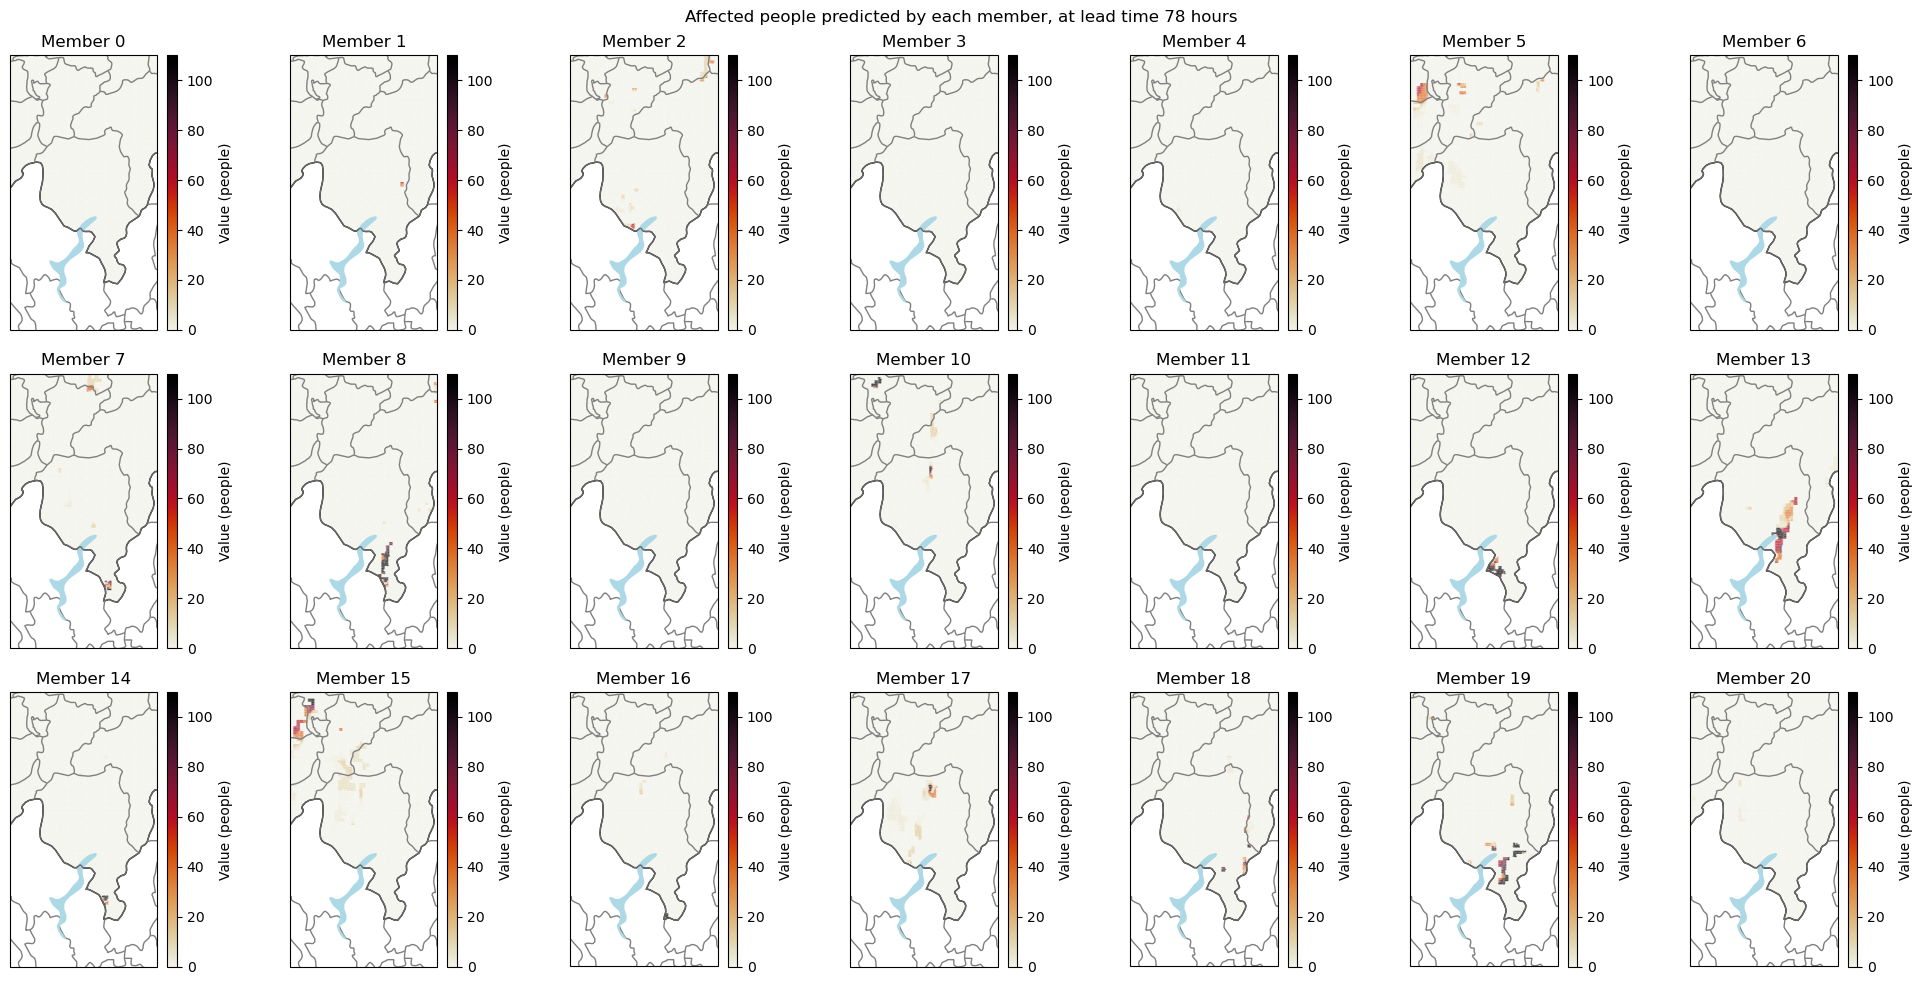

In [25]:
fig, ax = plt.subplots(
    3, 7, figsize=(20, 10), subplot_kw={"projection": ccrs.Mercator()}
)
fig.suptitle(f"Affected people predicted by each member, at lead time {test_lead_time}")
ax = ax.flatten()
for j, member in enumerate(imp_fct_all_mem_1lt.member):
    ax[j].add_feature(borders, linewidth=1)
    ax[j].add_feature(admin1, edgecolor="gray", linewidth=1.0, facecolor="none")
    ax[j].add_feature(lakes, facecolor="lightblue")

    # plot impact forecast
    imp_fct_all_mem_1lt.plot_hexbin_impact_exposure(
        event_id=imp_fct_all_mem_1lt.event_id[j],
        pop_name=False,
        axis=ax[j],
        vmin=0,
        vmax=110,
    )
    ax[j].set_extent(extent_ticino)
    ax[j].set_title(f"Member {j}")

Next, we can analyse the evolution of predicted number of affected people over Switzerland (member distribution shown as a histogram) with increasing forecast lead time.

### 3.3 All ensemble members and lead times

2026-04-10 14:04:12,232 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.
2026-04-10 14:04:12,237 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.
2026-04-10 14:04:12,240 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.
2026-04-10 14:04:12,244 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.
2026-04-10 14:04:12,247 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.
2026-04-10 14:04:12,251 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the

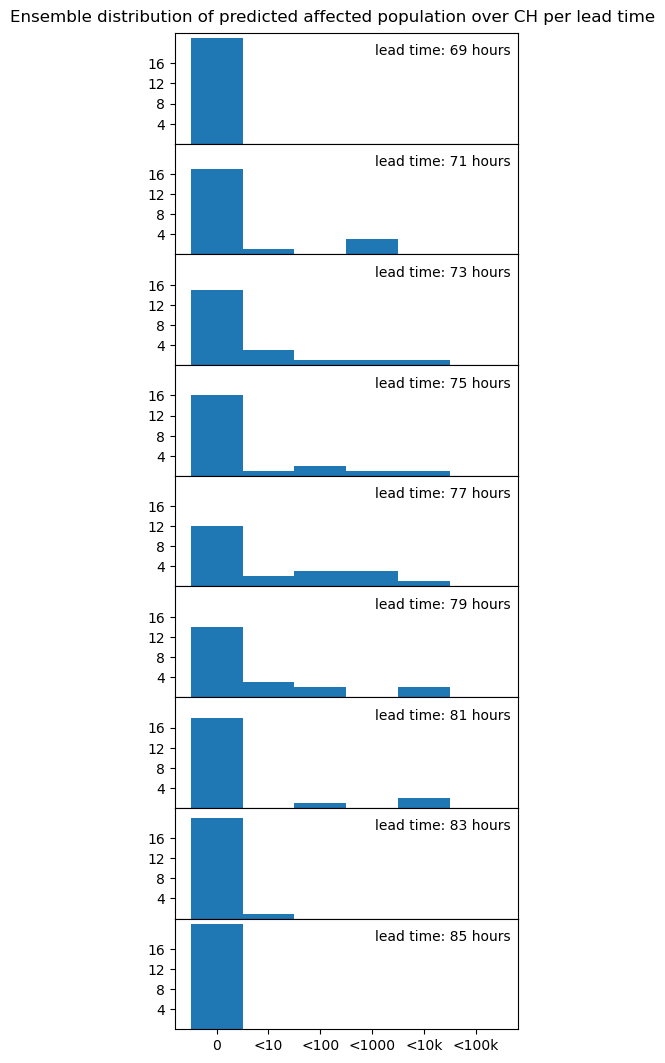

In [26]:
lead_time_window = np.timedelta64(1, "h") * np.arange(69, 87, 2)
n_lead_times = len(lead_time_window)

fig, ax = plt.subplots(
    nrows=n_lead_times,
    ncols=1,
    figsize=(4, 1.2 * n_lead_times),
    sharex=True,
    sharey=True,
)
ax = ax.flatten()
log_histogram_bins = np.arange(7)

for j, lead_time in enumerate(lead_time_window):
    imp_fct_all_mem_1lt = impact_forecast.select(lead_time=lead_time)
    imp_per_member = imp_fct_all_mem_1lt.imp_mat.sum(axis=1)
    ax[j].hist(np.log10(imp_per_member + 1), bins=log_histogram_bins, alpha=1)
    ax[j].set_yticks([4, 8, 12, 16])
    ax[j].text(
        0.98,
        0.90,
        f"lead time: {lead_time.astype('timedelta64[h]')}",
        ha="right",
        va="top",
        transform=ax[j].transAxes,
    )

ax[-1].set_xlabel("")

bin_centers = 0.5 * (log_histogram_bins[:-1] + log_histogram_bins[1:])
ax[-1].set_xticks(bin_centers)
ax[-1].set_xticklabels(["0", "<10", "<100", "<1000", "<10k", "<100k"])

plt.suptitle(
    "Ensemble distribution of predicted affected population over CH per lead time"
)
plt.tight_layout()
plt.subplots_adjust(hspace=0)

Attributes of an `ImpactForecast` object that do not make sense if impacts correspond to different ensemble members and lead times (instead of impacts of different events in a probabilistic event set as usual in `Impact` objects) are filled with NaNs.

In [27]:
print("average annual imact: ", impact_forecast.aai_agg)
print("average annual impact per centroid: ", impact_forecast.eai_exp)
try:
    impact_forecast.calc_freq_curve()
except NotImplementedError as e:
    print(e)

average annual imact:  nan
average annual impact per centroid:  [nan nan nan ... nan nan nan]
2026-04-10 14:04:12,386 - climada.engine.impact_forecast - ERROR - calc_freq_curve is not defined for ImpactForecast
calc_freq_curve is not defined for ImpactForecast


`ImpactForecast` objects can be written to and read from hdf5 files:

In [28]:
# write hazard forecast object to h5 file
with TemporaryDirectory() as tmpdir:
    impact_forecast.write_hdf5(Path(tmpdir) / "demo_impact_forecast.h5")

    # read hazard forecast from h5 file
    imp_fct = ImpactForecast.from_hdf5(Path(tmpdir) / "demo_impact_forecast.h5")

np.array_equal(impact_forecast.imp_mat.toarray(), imp_fct.imp_mat.toarray())

2026-04-10 14:04:12,412 - climada.engine.impact_forecast - INFO - at_event gives the total impact for one specific combination of member and lead_time.


True